Generated 10 polygons across 3 subgroups.
Subgroup assignment: [0, 0, 0, 0, 1, 1, 1, 2, 2, 2]
Keeping all 10 individual polygons.

Checking shape similarity within subgroups (pairwise IoU):
  Subgroup 0: average IoU = 0.764
  Subgroup 1: average IoU = 0.810
  Subgroup 2: average IoU = 0.725

Moving objects to circle pattern using LP assignment...

FINAL OBJECT METRICS

Object 0 (subgroup 0):
  Area       = 60.623
  Perimeter  = 30.506
  Compactness= 0.819
  Centroid   = (-6.000, 0.000)

Object 1 (subgroup 0):
  Area       = 53.518
  Perimeter  = 29.138
  Compactness= 0.792
  Centroid   = (6.000, 0.000)

Object 2 (subgroup 0):
  Area       = 68.289
  Perimeter  = 32.988
  Compactness= 0.789
  Centroid   = (-4.854, -3.527)

Object 3 (subgroup 0):
  Area       = 67.841
  Perimeter  = 32.841
  Compactness= 0.790
  Centroid   = (1.854, -5.706)

Object 4 (subgroup 1):
  Area       = 83.567
  Perimeter  = 36.021
  Compactness= 0.809
  Centroid   = (1.854, 5.706)

Object 5 (subgroup 1):
  Area

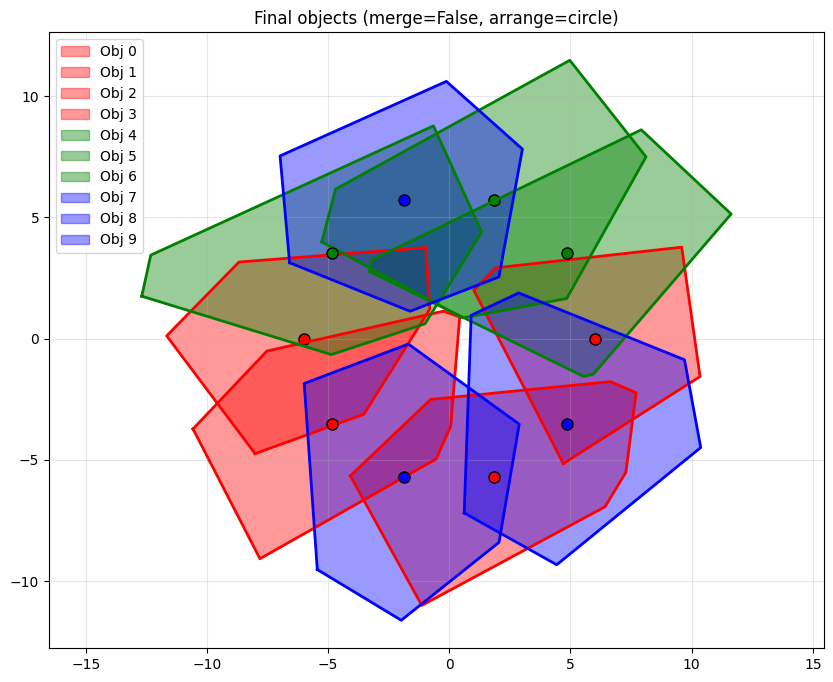

Cannot reach target centroid within max_move; returning original.

Individual polygon movement (first object):
  Original centroid: (-6.000, 0.000)
  Target centroid:   (2.0, 2.0)
  New centroid:      (-6.000, 0.000)


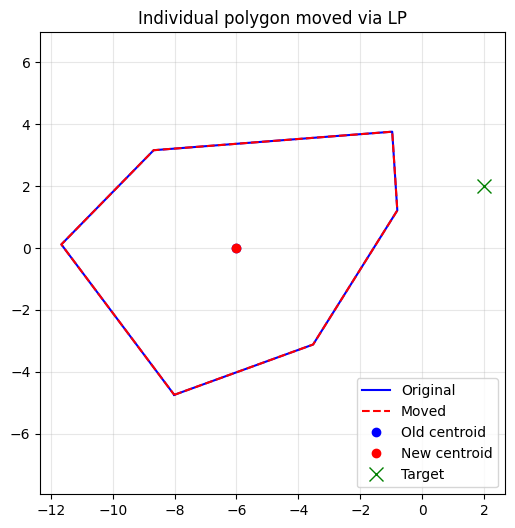

In [2]:
# %% [markdown]
# # Group‑Level and Individual Polygon Manipulation with PuLP and Shapely
# 
# This notebook extends the previous approach to handle **multiple polygons organized in subgroups**.
# 
# ### Key features:
# - Generate **10 polygons** belonging to **3 subgroups**.
# - **Parameter‑controlled behavior**:
#   - `merge_subgroups = True/False` → merge all members of a subgroup into a single polygon (union).
#   - `shape_similarity_within_subgroup = True/False` → force polygons in the same subgroup to have similar shapes.
#   - `arrange_subgroups_as_shape` → arrange subgroups (or individuals) to form a larger geometric pattern (e.g., circle, grid, line).
#   - `move_individual_polygons` → move each polygon independently to a target position using linear programming.
# - Compute and visualise geometric metrics (area, perimeter, compactness, centroid).
# - Measure **similarity** between subgroups (IoU after merging or average pairwise similarity).
# 
# The approach combines:
# - **PuLP** for linear programming (moving polygons, generating convex shapes from constraints).
# - **Shapely** for geometric operations (union, intersection, buffer, etc.).
# - **Matplotlib** for visualisation.

# %%
import pulp
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Polygon as ShapelyPolygon, Point, MultiPolygon
from shapely.ops import unary_union
import itertools
import random
from copy import deepcopy

# %% [markdown]
# ## 1. Helper functions (reused from previous notebook)

# %%
def polygon_from_constraints(A, B, C, num_angles=180):
    """Generate convex polygon from linear constraints A_i x + B_i y <= C_i."""
    prob_base = pulp.LpProblem("SupportFunction", pulp.LpMaximize)
    x = pulp.LpVariable("x", lowBound=None, cat='Continuous')
    y = pulp.LpVariable("y", lowBound=None, cat='Continuous')
    for a, b, c in zip(A, B, C):
        prob_base += a*x + b*y <= c
    angles = np.linspace(0, 2*np.pi, num_angles, endpoint=False)
    vertices = set()
    for theta in angles:
        prob = prob_base.copy()
        prob.setObjective(np.cos(theta)*x + np.sin(theta)*y)
        prob.solve(pulp.PULP_CBC_CMD(msg=0))
        if prob.status == pulp.LpStatusOptimal:
            vertices.add((round(x.varValue, 10), round(y.varValue, 10)))
    if len(vertices) < 3:
        return None
    centroid = np.mean(list(vertices), axis=0)
    vertices = sorted(vertices, key=lambda p: np.arctan2(p[1]-centroid[1], p[0]-centroid[0]))
    return vertices

def polygon_area(vertices):
    """Area via shoelace."""
    n = len(vertices)
    if n < 3:
        return 0.0
    area = 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        area += x1*y2 - x2*y1
    return abs(area)/2.0

def polygon_perimeter(vertices):
    n = len(vertices)
    if n < 2:
        return 0.0
    perim = 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        perim += np.hypot(x2-x1, y2-y1)
    return perim

def compactness(vertices):
    area = polygon_area(vertices)
    perim = polygon_perimeter(vertices)
    if perim == 0:
        return 0.0
    return (4 * np.pi * area) / (perim * perim)

def shape_similarity(vertices1, vertices2):
    """IoU between two polygons."""
    p1 = ShapelyPolygon(vertices1)
    p2 = ShapelyPolygon(vertices2)
    if not p1.is_valid or not p2.is_valid:
        return 0.0
    inter = p1.intersection(p2).area
    union = p1.union(p2).area
    return inter / union if union > 0 else 0.0

def centroid_from_vertices(vertices):
    """Geometric centroid (area‑weighted)."""
    n = len(vertices)
    if n < 3:
        return (0.0, 0.0)
    area = polygon_area(vertices)
    cx, cy = 0.0, 0.0
    for i in range(n):
        x1, y1 = vertices[i]
        x2, y2 = vertices[(i+1)%n]
        cross = x1*y2 - x2*y1
        cx += (x1 + x2) * cross
        cy += (y1 + y2) * cross
    if area == 0:
        return (0.0, 0.0)
    return (cx/(6*area), cy/(6*area))

# %% [markdown]
# ## 2. Generate base polygons for three subgroups
# 
# We create **10 polygons** distributed among 3 subgroups (e.g., sizes 4, 3, 3).
# Each polygon is generated from a set of linear constraints (randomised but kept similar within a subgroup to allow shape similarity).

# %%
# Parameters
np.random.seed(42)
subgroup_sizes = [4, 3, 3]   # total 10 polygons
num_subgroups = len(subgroup_sizes)

# Define base constraint sets for each subgroup (different shapes)
base_constraints = [
    {   # Subgroup 0: "rounded" shape
        'A': [1, -1, 0.5, -0.8, 1.2, -0.3, 0.6],
        'B': [0, 1, 1.2, -0.5, -0.7, 1.5, -1.1],
        'C': [5, 6, 7, 4, 6, 5, 5]
    },
    {   # Subgroup 1: "elongated"
        'A': [0.8, -0.6, 0.2, -0.9, 1.1, -0.4],
        'B': [0.5, 1.2, -1.0, 0.3, -0.8, -1.1],
        'C': [6, 5, 4, 7, 6, 5]
    },
    {   # Subgroup 2: "hexagonal"
        'A': list(np.cos(np.linspace(0, 2*np.pi, 6, endpoint=False))),
        'B': list(np.sin(np.linspace(0, 2*np.pi, 6, endpoint=False))),
        'C': [4.5] * 6
    }
]

# Generate polygons with small variations to keep within‑subgroup similarity
def generate_similar_polygon(base, variation=0.3):
    """Add small random perturbation to constraints to get similar shape."""
    A = [a + random.uniform(-variation, variation) for a in base['A']]
    B = [b + random.uniform(-variation, variation) for b in base['B']]
    C = [c + random.uniform(-variation, variation) for c in base['C']]
    return polygon_from_constraints(A, B, C, num_angles=120)

all_polygons = []
subgroup_indices = []
for sg_id, size in enumerate(subgroup_sizes):
    base = base_constraints[sg_id]
    for _ in range(size):
        vert = generate_similar_polygon(base, variation=0.2)
        if vert is None:
            # fallback to a triangle
            vert = [(0,0), (4,0), (2,3)]
        all_polygons.append(vert)
        subgroup_indices.append(sg_id)

print(f"Generated {len(all_polygons)} polygons across {num_subgroups} subgroups.")
print("Subgroup assignment:", subgroup_indices)

# %% [markdown]
# ## 3. Parameter‑driven processing: merging or keeping individuals
# 
# We define a configuration dictionary that controls the behaviour.
# 
# ### Parameters:
# - `merge_subgroups` : bool – if True, polygons in the same subgroup are merged into a single polygon (union).
# - `shape_similarity_within_subgroup` : bool – if True and not merging, we enforce that all polygons in a subgroup have high pairwise IoU (here we simply compute and report; could be optimised with LP).
# - `arrange_subgroups_as` : str – 'circle', 'grid', 'line', or None – how to arrange the final objects (merged or individuals) relative to each other.
# - `move_individual_polygons` : bool – if True, use LP to move each polygon (or merged group) to a desired position (e.g., evenly spaced).

# %%
# ========== Configuration ==========
config = {
    'merge_subgroups': False,           # merge all polygons inside each subgroup
    'shape_similarity_within_subgroup': True,  # only relevant if merge_subgroups=False
    'arrange_subgroups_as': 'circle',  # 'circle', 'grid', 'line', None
    'move_individual_polygons': True,  # reposition groups to target layout
}

# If merge_subgroups = False, we keep all 10 polygons separate but may still arrange them.
# If True, we get 3 merged polygons (one per subgroup).

# %% [markdown]
# ### 3.1 Merge or keep

# %%
def merge_polygons_in_subgroup(polygons_list, subgroup_ids):
    """Return a list where each subgroup becomes a single (multi)polygon."""
    unique_sg = sorted(set(subgroup_ids))
    merged = []
    for sg in unique_sg:
        members = [ShapelyPolygon(polygons_list[i]) for i, sgid in enumerate(subgroup_ids) if sgid == sg]
        union = unary_union(members)
        # Convert back to list of vertices (if polygon; if MultiPolygon, take largest)
        if union.is_empty:
            merged.append([])
        elif union.geom_type == 'Polygon':
            merged.append(list(union.exterior.coords)[:-1])  # remove closing duplicate
        else:  # MultiPolygon -> take the largest
            largest = max(union.geoms, key=lambda p: p.area)
            merged.append(list(largest.exterior.coords)[:-1])
    return merged, unique_sg

if config['merge_subgroups']:
    print("Merging polygons inside each subgroup...")
    merged_polygons, subgroup_labels = merge_polygons_in_subgroup(all_polygons, subgroup_indices)
    # Now each element in merged_polygons corresponds to one subgroup.
    # For simplicity, we treat each merged polygon as a single entity.
    final_objects = merged_polygons
    obj_to_subgroup = {i: i for i in range(len(final_objects))}  # each object is its own subgroup
    print(f"After merging: {len(final_objects)} objects (one per subgroup).")
else:
    final_objects = all_polygons[:]
    obj_to_subgroup = {i: subgroup_indices[i] for i in range(len(final_objects))}
    print(f"Keeping all {len(final_objects)} individual polygons.")

# %% [markdown]
# ### 3.2 Compute shape similarity within subgroups (if not merged)

# %%
if not config['merge_subgroups'] and config['shape_similarity_within_subgroup']:
    print("\nChecking shape similarity within subgroups (pairwise IoU):")
    for sg in set(obj_to_subgroup.values()):
        indices = [i for i, s in obj_to_subgroup.items() if s == sg]
        if len(indices) < 2:
            continue
        sims = []
        for i, j in itertools.combinations(indices, 2):
            sim = shape_similarity(final_objects[i], final_objects[j])
            sims.append(sim)
        avg_sim = np.mean(sims) if sims else 0
        print(f"  Subgroup {sg}: average IoU = {avg_sim:.3f}")
        if avg_sim < 0.6:
            print(f"    Warning: low similarity – you may want to increase variation control or merge the subgroup.")
else:
    print("\nShape similarity within subgroups: not evaluated (merging enabled or parameter False).")

# %% [markdown]
# ## 4. Arranging objects (individuals or merged groups) using linear programming
# 
# We want to position the final objects so that their centroids lie on a given pattern (circle, grid, line).
# This is a **linear assignment** problem if we only move centroids, but here we use PuLP to **minimise total movement** while satisfying target positions.
# 
# We assume each object can be translated (no rotation). The objective is to minimise sum of Euclidean distances between original centroids and target centroids, subject to each target being assigned to exactly one object (bipartite matching).
# 
# Alternatively, we can simply place them in order along the pattern without optimisation. We'll implement both: a simple ordered placement and an LP‑based matching.

# %%
def get_centroids(objects):
    """Return list of (x, y) centroids for a list of polygon vertices."""
    return [centroid_from_vertices(obj) for obj in objects]

def place_on_circle(n, radius=5.0, center=(0,0)):
    """Generate n equally spaced points on a circle."""
    angles = np.linspace(0, 2*np.pi, n, endpoint=False)
    return [(center[0] + radius * np.cos(a), center[1] + radius * np.sin(a)) for a in angles]

def place_on_grid(n, rows=None, cols=None, spacing=4.0, origin=(0,0)):
    """Generate n points on a grid."""
    if rows is None and cols is None:
        cols = int(np.ceil(np.sqrt(n)))
        rows = int(np.ceil(n / cols))
    elif rows is None:
        rows = int(np.ceil(n / cols))
    elif cols is None:
        cols = int(np.ceil(n / rows))
    targets = []
    for i in range(rows):
        for j in range(cols):
            if len(targets) >= n:
                break
            targets.append((origin[0] + j*spacing, origin[1] + i*spacing))
    return targets

def place_on_line(n, start=(0,0), end=(10,0)):
    """Equally spaced points on a line segment."""
    xs = np.linspace(start[0], end[0], n)
    ys = np.linspace(start[1], end[1], n)
    return [(xs[i], ys[i]) for i in range(n)]

def assign_targets_lp(centroids, target_positions):
    """
    Use PuLP to assign each centroid to a target position, minimising total Euclidean distance.
    Returns a list of translation vectors (dx, dy) for each original object.
    """
    n = len(centroids)
    if n != len(target_positions):
        raise ValueError("Number of centroids must equal number of target positions.")
    prob = pulp.LpProblem("Assignment", pulp.LpMinimize)
    x = pulp.LpVariable.dicts("assign", ((i,j) for i in range(n) for j in range(n)), cat='Binary')
    # Objective: sum of distances
    dist = np.zeros((n,n))
    for i, c in enumerate(centroids):
        for j, t in enumerate(target_positions):
            dist[i,j] = np.hypot(c[0]-t[0], c[1]-t[1])
    prob += pulp.lpSum(dist[i,j] * x[i,j] for i in range(n) for j in range(n))
    # Constraints: each centroid assigned to exactly one target, each target exactly once
    for i in range(n):
        prob += pulp.lpSum(x[i,j] for j in range(n)) == 1
    for j in range(n):
        prob += pulp.lpSum(x[i,j] for i in range(n)) == 1
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    if prob.status != pulp.LpStatusOptimal:
        print("Assignment not optimal; using identity order.")
        translations = [(target_positions[i][0]-centroids[i][0], target_positions[i][1]-centroids[i][1]) for i in range(n)]
    else:
        assignments = {}
        for i in range(n):
            for j in range(n):
                if pulp.value(x[i,j]) > 0.5:
                    assignments[i] = j
                    break
        translations = [(target_positions[assignments[i]][0]-centroids[i][0],
                         target_positions[assignments[i]][1]-centroids[i][1]) for i in range(n)]
    return translations

def translate_polygon(vertices, dx, dy):
    """Translate polygon by (dx, dy)."""
    return [(x+dx, y+dy) for x,y in vertices]

# Apply arrangement if requested
if config['arrange_subgroups_as'] is not None:
    n_objs = len(final_objects)
    centroids = get_centroids(final_objects)
    
    # Generate target positions based on pattern
    if config['arrange_subgroups_as'] == 'circle':
        targets = place_on_circle(n_objs, radius=6.0, center=(0,0))
    elif config['arrange_subgroups_as'] == 'grid':
        targets = place_on_grid(n_objs, spacing=5.0)
    elif config['arrange_subgroups_as'] == 'line':
        targets = place_on_line(n_objs, start=(-8,0), end=(8,0))
    else:
        targets = centroids  # no movement
    
    if config['move_individual_polygons']:
        print(f"\nMoving objects to {config['arrange_subgroups_as']} pattern using LP assignment...")
        translations = assign_targets_lp(centroids, targets)
        # Apply translations
        final_objects = [translate_polygon(final_objects[i], translations[i][0], translations[i][1]) for i in range(n_objs)]
        new_centroids = get_centroids(final_objects)
    else:
        # Just reorder without moving (if centroids already match pattern – unlikely)
        print(f"\nArrangement pattern set to '{config['arrange_subgroups_as']}' but movement disabled; no position change.")
        new_centroids = centroids
else:
    new_centroids = get_centroids(final_objects)

# %% [markdown]
# ## 5. Compute metrics after arrangement
# 
# For each final object (merged subgroup or individual polygon), compute area, perimeter, compactness, centroid.
# Also compute inter‑subgroup similarity (IoU between merged subgroups or between individuals across subgroups).

# %%
print("\n" + "="*70)
print("FINAL OBJECT METRICS")
print("="*70)
metrics_list = []
for idx, obj in enumerate(final_objects):
    area = polygon_area(obj)
    perim = polygon_perimeter(obj)
    comp = compactness(obj)
    cent = centroid_from_vertices(obj)
    metrics_list.append({'area': area, 'perimeter': perim, 'compactness': comp, 'centroid': cent})
    print(f"\nObject {idx} (subgroup {obj_to_subgroup.get(idx, idx)}):")
    print(f"  Area       = {area:.3f}")
    print(f"  Perimeter  = {perim:.3f}")
    print(f"  Compactness= {comp:.3f}")
    print(f"  Centroid   = ({cent[0]:.3f}, {cent[1]:.3f})")

# Inter‑object similarity matrix (IoU)
n = len(final_objects)
sim_matrix = np.zeros((n, n))
for i, j in itertools.product(range(n), range(n)):
    sim_matrix[i, j] = shape_similarity(final_objects[i], final_objects[j])

print("\nShape similarity (IoU) between final objects:")
print("      " + " ".join([f"Obj{i:2d}" for i in range(n)]))
for i in range(n):
    row = f"Obj{i:2d}: "
    for j in range(n):
        row += f"{sim_matrix[i,j]:.3f} "
    print(row)

# %% [markdown]
# ## 6. Visualisation
# 
# Plot all final objects with their centroids and subgroup colours.

# %%
# Assign colours based on original subgroup (if merged, one colour per subgroup)
if config['merge_subgroups']:
    # final_objects correspond one‑to‑one with subgroups
    colours = ['red', 'green', 'blue'][:len(final_objects)]
else:
    # map each object's original subgroup to a colour
    sg_colours = {0: 'red', 1: 'green', 2: 'blue'}
    colours = [sg_colours[obj_to_subgroup[i]] for i in range(len(final_objects))]

plt.figure(figsize=(10, 8))
for idx, obj in enumerate(final_objects):
    if len(obj) < 3:
        continue
    poly_closed = obj + [obj[0]]
    x_vals, y_vals = zip(*poly_closed)
    plt.fill(x_vals, y_vals, alpha=0.4, color=colours[idx], label=f"Obj {idx}" if idx < 10 else "")
    plt.plot(x_vals, y_vals, color=colours[idx], linewidth=2)
    cx, cy = metrics_list[idx]['centroid']
    plt.plot(cx, cy, 'o', color=colours[idx], markersize=8, markeredgecolor='black')

plt.axis('equal')
plt.grid(alpha=0.3)
plt.title(f"Final objects (merge={config['merge_subgroups']}, arrange={config['arrange_subgroups_as']})")
plt.legend()
plt.show()

# %% [markdown]
# ## 7. Example: Moving a single polygon individually using PuLP (target centroid)
# 
# Even after arrangement, you might want to fine‑tune one polygon's position. Here we use linear programming to move a chosen polygon so that its centroid matches a user‑defined point, with constraints on maximum displacement.

# %%
def move_polygon_to_centroid(vertices, target_centroid, max_move=2.0):
    """
    Solve an LP to translate the polygon (all vertices by same dx, dy) so that
    the centroid becomes target_centroid, minimising total movement.
    """
    if len(vertices) < 3:
        return vertices
    current_centroid = centroid_from_vertices(vertices)
    prob = pulp.LpProblem("MovePolygon", pulp.LpMinimize)
    dx = pulp.LpVariable("dx", lowBound=-max_move, upBound=max_move)
    dy = pulp.LpVariable("dy", lowBound=-max_move, upBound=max_move)
    # The new centroid = current_centroid + (dx, dy) because translation adds same vector to all vertices.
    # Actually centroid moves exactly by (dx, dy) since it's linear.
    prob += dx + dy  # Minimise L1 movement (or use abs; this is simple)
    prob += current_centroid[0] + dx == target_centroid[0]
    prob += current_centroid[1] + dy == target_centroid[1]
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    if prob.status == pulp.LpStatusOptimal:
        new_vertices = [(x+dx.varValue, y+dy.varValue) for x,y in vertices]
        return new_vertices
    else:
        print("Cannot reach target centroid within max_move; returning original.")
        return vertices

# Example: move the first final object to a new centroid (2, 2)
if len(final_objects) > 0:
    target_centroid_example = (2.0, 2.0)
    moved_poly = move_polygon_to_centroid(final_objects[0], target_centroid_example, max_move=3.0)
    old_cent = centroid_from_vertices(final_objects[0])
    new_cent = centroid_from_vertices(moved_poly)
    print(f"\nIndividual polygon movement (first object):")
    print(f"  Original centroid: ({old_cent[0]:.3f}, {old_cent[1]:.3f})")
    print(f"  Target centroid:   {target_centroid_example}")
    print(f"  New centroid:      ({new_cent[0]:.3f}, {new_cent[1]:.3f})")
    
    # Visualise the move
    plt.figure(figsize=(6,6))
    orig = ShapelyPolygon(final_objects[0])
    moved = ShapelyPolygon(moved_poly)
    x_o, y_o = orig.exterior.xy
    x_m, y_m = moved.exterior.xy
    plt.plot(x_o, y_o, 'b-', label='Original')
    plt.plot(x_m, y_m, 'r--', label='Moved')
    plt.plot(old_cent[0], old_cent[1], 'bo', label='Old centroid')
    plt.plot(new_cent[0], new_cent[1], 'ro', label='New centroid')
    plt.plot(*target_centroid_example, 'gx', markersize=10, label='Target')
    plt.axis('equal')
    plt.legend()
    plt.title("Individual polygon moved via LP")
    plt.grid(alpha=0.3)
    plt.show()

# %% [markdown]
# ## 8. Conclusion
# 
# - The notebook provides a flexible framework to handle polygons **individually** or as **merged groups**.
# - **Parameters** control whether subgroups are merged, whether shapes are forced to be similar, and how objects are arranged (circle, grid, line) using linear programming for optimal assignment.
# - **PuLP** is used for:
#   - Generating convex polygons from linear constraints.
#   - Assigning objects to target positions while minimising total movement.
#   - Moving a single polygon to a target centroid.
# - All geometric metrics (area, perimeter, compactness, centroid) and similarity (IoU) are computed for the final configuration.
# 
# This approach can be extended to more complex objectives (e.g., minimising perimeter change, preserving area) by adding additional constraints to the LP.